In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import pickle
import corner
from pathlib import Path
import math

In [2]:

tmids_outerdf_path = Path("../Data/kepler9_holczer_outer.csv")
tmids_outer_df = pd.read_csv(tmids_outerdf_path)
tmids_outer = tmids_outer_df['tmid']
tmid0_outer = tmids_outer[0]
tmids_linephem = tmids_outer_df['tn']

print(f"tmids outer : {tmids_outer}")
print(f"linear ephemerus tmids outer : {tmids_linephem}")

tmids outer : 0      136.306699
1      175.331925
2      214.336663
3      253.313000
4      292.263433
5      331.182548
6      370.072217
7      408.931054
8      447.765862
9      486.578032
10     525.377979
11     564.169732
12     602.959540
13     641.753932
14     680.562768
15     758.237038
16     797.113097
17     836.022072
18     874.963894
19     913.935717
20     952.933303
21     991.954432
22    1031.000906
23    1109.117190
24    1148.184707
25    1187.257640
26    1226.332171
27    1265.405382
28    1304.479358
29    1343.553194
30    1382.624808
31    1421.698852
32    1460.769495
33    1499.835275
34    1538.903834
35    1577.962322
Name: tmid, dtype: float64
linear ephemerus tmids outer : 0      135.896213
1      174.846022
2      213.795830
3      252.745639
4      291.695447
5      330.645256
6      369.595064
7      408.544873
8      447.494681
9      486.444490
10     525.394298
11     564.344107
12     603.293915
13     642.243724
14     681.193532
15     759

In [3]:
#load in curves and info from mcmc

In [6]:
with open("../Outputs/datainfo_kepler9c.pkl", "rb") as f:
    mcmcresults = pickle.load(f)
    
curves = mcmcresults["curves"]
info = mcmcresults["info"]
ncurves = info["ncurves"]
tmidi_calc = []
for i, curve in enumerate(curves):
    tmidi_i = curve["tmidi"]
    tmidi_calc.append(tmidi_i)
#print(tmidi_calc - tmids_linephem)


In [7]:
print(tmidi_calc)


[np.float64(135.896213), np.float64(174.846022), np.float64(213.79583), np.float64(252.745639), np.float64(291.695447), np.float64(330.645256), np.float64(369.595064), np.float64(408.544873), np.float64(447.494681), np.float64(486.44449), np.float64(525.3942979999999), np.float64(564.344107), np.float64(603.293915), np.float64(642.243724), np.float64(681.193532), np.float64(759.093149), np.float64(798.042958), np.float64(836.992766), np.float64(914.892384), np.float64(1031.741809), np.float64(1109.641426), np.float64(1148.591235), np.float64(1187.541043), np.float64(1226.490852), np.float64(1265.44066), np.float64(1304.390469), np.float64(1343.340277), np.float64(1382.290086), np.float64(1421.239894), np.float64(1460.189703), np.float64(1499.139511), np.float64(1538.08932), np.float64(1577.039128)]


In [8]:
### load in nonlinear mcmc

In [9]:
nonlinear_posterior = az.from_netcdf("../Outputs/arviz_kepler9c_nonlinear.nc")
burnin = info["burnin"]
nonlinear_posterior = nonlinear_posterior.sel(draw=slice(burnin, None))
nonlinear_results = mcmcresults["nonlinear_results"]
tmids_nonlinear = nonlinear_results["nonlinear_psi_samps"] 
print(nonlinear_posterior.posterior)
print(nonlinear_posterior.sample_stats)
az.summary(nonlinear_posterior)

<xarray.Dataset> Size: 24MB
Dimensions:   (chain: 12, draw: 50000)
Coordinates:
  * chain     (chain) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * draw      (draw) int64 400kB 50000 50001 50002 50003 ... 99997 99998 99999
Data variables:
    p         (chain, draw) float64 5MB ...
    b         (chain, draw) float64 5MB ...
    ln_rho_s  (chain, draw) float64 5MB ...
    q1        (chain, draw) float64 5MB ...
    q2        (chain, draw) float64 5MB ...
Attributes:
    created_at:                 2025-12-27T13:19:37.772806+00:00
    arviz_version:              0.23.0
    inference_library:          emcee
    inference_library_version:  3.1.6
<xarray.Dataset> Size: 5MB
Dimensions:  (chain: 12, draw: 50000)
Coordinates:
  * chain    (chain) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * draw     (draw) int64 400kB 50000 50001 50002 50003 ... 99997 99998 99999
Data variables:
    lp       (chain, draw) float64 5MB ...
Attributes:
    created_at:                 2025-12-27T13:19:37.735225+00:00
    ar

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.077,0.001,0.076,0.078,0.000,0.000,5501.0,11967.0,1.0
b,0.765,0.007,0.752,0.778,0.000,0.000,6732.0,16317.0,1.0
ln_rho_s,7.255,0.032,7.202,7.313,0.000,0.000,7456.0,20779.0,1.0
q1,0.417,0.054,0.315,0.517,0.001,0.000,5208.0,11682.0,1.0
q2,0.271,0.135,0.100,0.515,0.002,0.001,5753.0,10788.0,1.0


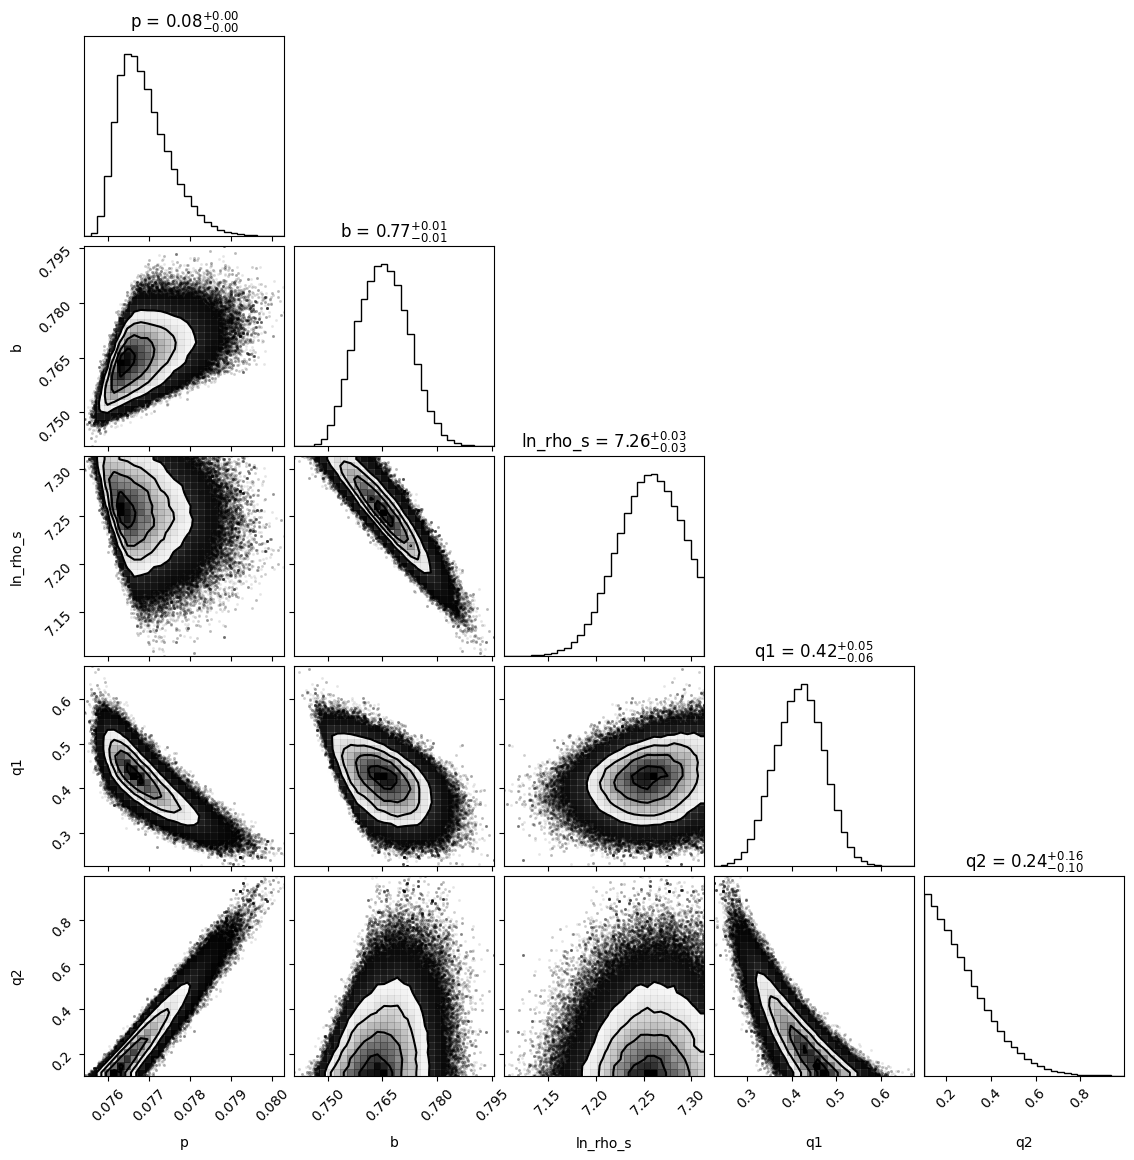

In [10]:
ds = nonlinear_posterior.posterior

posterior_flat = ds.to_array().stack(sample=("chain", "draw")).transpose()
samples = posterior_flat.values

param_names = list(ds.data_vars)

fig = corner.corner(
    samples,
    labels=param_names,
    bins=30,
    show_titles=True,
    title_fmt=".2f",
)

plt.show()


In [ ]:
#### get median and +/- 1$\sigma$ tmid values from each one

In [ ]:


# ###linear calc
# ncurves = info["ncurves"]

# tts_l_median = []
# tts_l_err = []
# for ii in range(0, ncurves):
#     tts_l = np.median(linear_posterior.posterior[f"tmid{ii}"].values)
#     tts_l_median.append(tts_l)
    
    
#     tts_l_quantile = [np.quantile(linear_posterior.posterior[f"tmid{ii}"].values, 0.16),
#                     np.quantile(linear_posterior.posterior[f"tmid{ii}"].values, 0.84)]
    
#     tts_l_err.append(np.array([
#         tts_l - tts_l_quantile[0],
#         tts_l_quantile[1] - tts_l
#     ]))
    
#     print(f"linear: relative tmid{ii} {tts_l}, and 1 sigma {tts_l_err[ii]}")
    

# tts_l_err = np.array(tts_l_err).T



In [ ]:
### get tmids from non linear blobs

In [11]:
nonlinear_results = mcmcresults["nonlinear_results"]
tmids_nonlinear = nonlinear_results["nonlinear_psi_samps"] 
print(tmids_nonlinear.shape)

###nonlinear calc
ncurves = info["ncurves"]

tts_l_median = []
tts_l_err = []
for ii in range(0, ncurves):
    tts_l = np.median(tmids_nonlinear[:, ii])
    tts_l_median.append(tts_l)
    
    
    tts_l_quantile = [np.quantile(tmids_nonlinear[:, ii], 0.16),
                    np.quantile(tmids_nonlinear[:, ii], 0.84)]
    
    tts_l_err.append(np.array([
        tts_l - tts_l_quantile[0],
        tts_l_quantile[1] - tts_l
    ]))
    
    print(f"nonlinear: relative tmid{ii} {tts_l}")
    

tts_l_err = np.array(tts_l_err).T





(60000, 33)
nonlinear: relative tmid0 0.41033871489409535
nonlinear: relative tmid1 0.4850425606893225
nonlinear: relative tmid2 0.5404670348885077
nonlinear: relative tmid3 0.567883373689682
nonlinear: relative tmid4 0.567379641256025
nonlinear: relative tmid5 0.5398078312443886
nonlinear: relative tmid6 0.4763763553814897
nonlinear: relative tmid7 0.38501019467597075
nonlinear: relative tmid8 0.26955688271658573
nonlinear: relative tmid9 0.13322860590585606
nonlinear: relative tmid10 -0.016554158857047696
nonlinear: relative tmid11 -0.17503943936372934
nonlinear: relative tmid12 -0.3351869613103986
nonlinear: relative tmid13 -0.4903935433428046
nonlinear: relative tmid14 -0.6315514965000943
nonlinear: relative tmid15 -0.85483543437158
nonlinear: relative tmid16 -0.930688120580669
nonlinear: relative tmid17 -0.9713115488066819
nonlinear: relative tmid18 -0.9575867562005556
nonlinear: relative tmid19 -0.7410397528368549
nonlinear: relative tmid20 -0.524345745424398
nonlinear: relative 

In [12]:
### print relative tmid holczer

In [13]:
tmid_relative_holczer0 = tmids_outer[0] - tmids_linephem[0]
print(tmid_relative_holczer0)

0.410486111111112


In [14]:
tmid_relative_holczer = tmids_outer - tmids_linephem
print(tmid_relative_holczer.shape)


(36,)


In [15]:
#### make O-C diagram

36
33


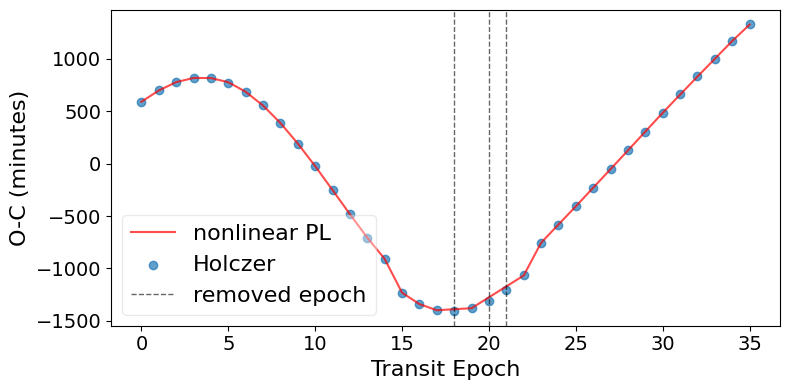

<Figure size 640x480 with 0 Axes>

In [21]:
###plot time from linear ephemeris
#pop holczer results for bad data epochs
#print(tmid_relative_holczer.shape)
#print(type(tmid_relative_holczer))
bad_epochs = [18, 20, 21]

tmid_relative_holczer = tmids_outer - tmids_linephem
epochs_full = tmid_relative_holczer.index
good_epochs = epochs_full[~epochs_full.isin(bad_epochs)]
# tmid_relative_holczer_plot = tmid_relative_holczer.reindex(epochs_full).copy()
# tmid_relative_holczer_plot.loc[bad_epochs] = np.nan


best_tmids_nonlinear = nonlinear_results["nonlinear_best_psi_samp"]
best_tmids_nonlinear_plot = pd.Series(np.nan, index=epochs_full, dtype=float)
best_tmids_nonlinear_plot.loc[good_epochs] = best_tmids_nonlinear
best_tmids_nonlinear_plot_clean = best_tmids_nonlinear_plot.dropna()


print(len(tmid_relative_holczer))
print(len(best_tmids_nonlinear))
nstd = 1

plt.figure(figsize=(8, 4))

plt.plot(
    best_tmids_nonlinear_plot_clean.index, best_tmids_nonlinear_plot_clean.values*1440,  alpha=0.7, label="nonlinear PL", c = 'r'
)

plt.scatter(
    tmid_relative_holczer.index, tmid_relative_holczer.values*1440,  alpha=0.7, label="Holczer"
)
# plt.errorbar(
#     x, best_tmids_linear, yerr=nstd*tts_l_err,
#     fmt='-o', capsize=3, alpha=0.7, label="linear"
# )
for j, e in enumerate(bad_epochs):
    plt.axvline(
        e,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
        color="k",
        label="removed epoch" if j == 0 else None
    )
plt.tick_params(axis="both", which="major", labelsize=14)
plt.xlabel("Transit Epoch", fontsize = 16)
plt.ylabel("O-C (minutes)", fontsize = 16)
plt.legend(fontsize = 16  ,  framealpha=0.4, )

plt.tight_layout()
plt.show()
plt.savefig("kepler9c_oc.pdf", bbox_inches="tight", pad_inches = .02)

In [ ]:
# --- NONLINEAR TMID HISTOGRAMS ONLY ---

ncurves = info["ncurves"]
print(ncurves)
tmid_nonlin_samples = 

labels = [f"tmid_{i}" for i in range(ncurves)]

fig, axes = plt.subplots(
    nrows=ncurves, ncols=1,
    figsize=(7, 2.5 * ncurves),
    sharex=False
)

# Make axes iterable even if ncurves == 1
if ncurves == 1:
    axes = [axes]

for i, ax in enumerate(axes):

    ax.hist(
        tmid_nonlin_samples[:, i],
        bins=40,
        alpha=0.7,
        density=True,
        label="nonlinear"
    )

    # Optional truth marker
    if 'tmids_outer' in globals():
        ax.axvline(tmid_relative_holczer[i], linestyle="--", color="k")

    ax.set_ylabel(labels[i])

axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()


In [ ]:
best_flux_prof = nonlinear_results["best_flux_prof"]
for i, curve, in enumerate(curves):
    t = curve["t"]
    flux_data = curve["flux"]
    plt.figure(figsize=(6, 4))
    plt.scatter(t, flux_data, s=5, alpha=0.6, label="Data")
    plt.plot(t, best_flux_prof[i], lw=1.5, label="Best MCMC model")
    plt.xlabel("Time")
    plt.ylabel("Flux")
    plt.title(f"Curve {i}: data vs best model")
    plt.legend()
    plt.tight_layout()

In [ ]:
# --- LINEAR TMID HISTOGRAMS ONLY ---

ncurves = info["ncurves"]

tmid_lin_samples = np.vstack([
    tmids_linephem[i] + linear_posterior.posterior[f"tmid{i}"].values.reshape(-1)
    for i in range(ncurves)
]).T

labels = [f"tmid_{i}" for i in range(ncurves)]

fig, axes = plt.subplots(
    nrows=ncurves, ncols=1,
    figsize=(7, 2.5 * ncurves),
    sharex=False
)

if ncurves == 1:
    axes = [axes]

for i, ax in enumerate(axes):

    ax.hist(
        tmid_lin_samples[:, i],
        bins=40,
        alpha=0.7,
        density=True,
        label="linear"
    )

    # Optional truth marker
    if 'tmids_outer' in globals():
        ax.axvline(tmids_outer[i], linestyle="--", color="k")

    ax.set_ylabel(labels[i])

axes[0].legend(loc="upper right")

plt.tight_layout()
plt.show()
